# SEIHRV model

## Table Of Contents

- [Adding Vaccination](#SEIHRV) 
  > •[Using Two Functions](#SEIHRV2funcs)  
  > •[Using a 'Vaccine' function](#SEIHRVVaxfunc)  
  > •[Adding Vaccinated Susceptible Compartment](#SEIHRVVaxsusc)  

Adding vaccination to the previous SEIHR model. We want to consider a vaccine with efficacy $\eta \in [0,1]$. I will do a few different types, building up to being able to implement the vaccine at a certain day.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as spi

## Adding vaccination from day 1 <a id="SEIHRV"></a>

This consists of just editing the SEIHR model by adding an equation for $\frac{dV}{dt}$. It matches the compartmental model I drew (see Goodnotes) where Susceptibles are being vaccinated at a rate $\sigma$, and then of those in 'Vaccinated', some move into exposed at a rate $(1 - \eta)\lambda$ to represent the efficacy of the vaccine. The differential equations here are:

$$\dfrac{dS}{dt} = - \lambda \frac{S}{N} + \omega R - \sigma S$$ 

$$\dfrac{dE}{dt} =  \lambda \frac{S}{N} - \epsilon E + (1 - \eta)\lambda \frac{V}{N}$$ 

$$\dfrac{dI^S}{dt} = \epsilon d E - \gamma I^S$$

$$\dfrac{dI^A}{dt} = \epsilon (1-d) E - \gamma I^A$$

$$\dfrac{dH}{dt} = \gamma h I^S - \delta H$$

$$\dfrac{dR}{dt} = \delta H + \gamma (1 - h)I^S + \gamma I^A - \omega R$$

$$\dfrac{dV}{dt} = \sigma S - (1 - \eta)\lambda \frac{V}{N} $$

The new terms are:

- $\sigma$: rate of vaccination

- $\eta$: efficacy of the vaccine

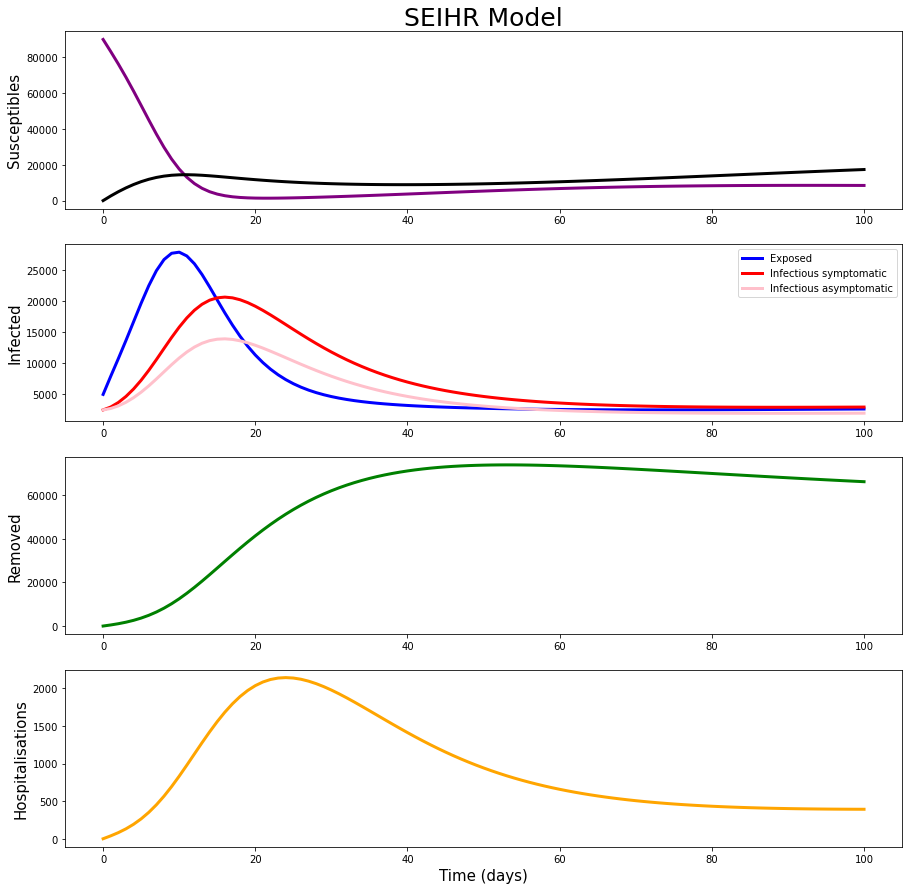

In [3]:
# Rates
beta = 1.4247 
epsilon = 1/5.28
gamma = 1/10 
delta = 1/8.78 
tau = 0.25 
rho = 0.1
omega = 1/100
d = 0.6
h = 0.15 

# Population sizes
N = 100000   #total
S0 = 90000
E0 = 5000
I_S0 = 2500
I_A0 = 2500
H0 = 0
R0 = 0
V0 = 0

# Time values
t_start = 0
days = 100
t_step=1.0

# Vaccination parameters
sigma = 0.03   #rate of vaccination
eta = 0.9   #efficacy of vaccine


InitialVals = [S0, E0, I_S0, I_A0, H0, R0, V0]

def SEIHRVmodel(IVS,time):  
    
    FOI = beta*(tau*IVS[3] + IVS[2] + rho*IVS[4]) #force of infection depends on number of infected people
    
    S = - FOI * IVS[0]/N + omega*IVS[5] - sigma*IVS[0]
    E = FOI * IVS[0]/N - epsilon*IVS[1] + (1 - eta)*FOI*IVS[6]/N
    I_S = epsilon*d*IVS[1] - gamma*IVS[2]
    I_A = epsilon*(1 - d)*IVS[1] - gamma*IVS[3]
    H = gamma*h*IVS[2] - delta*IVS[4]
    R = delta*IVS[4] + gamma*(1 - h)*IVS[2] + gamma*IVS[3] - omega*IVS[5]
    V = sigma*IVS[0] - (1 - eta)*FOI*IVS[6]/N
    
    Y = [S, E, I_S, I_A, H, R, V]
    return(Y) 


t = np.arange(t_start, days+t_step, t_step)
values = spi.odeint(SEIHRVmodel, InitialVals, t)


# Plotting:
plt.figure(figsize=(15, 15))


plt.subplot(411)
plt.plot(values[:,0], 'purple', linewidth = 3, label='Susceptible')
plt.plot(values[:,6], 'black', linewidth = 3, label='Vaccinated')
plt.title('SEIHR Model', fontsize=25)
plt.ylabel('Susceptibles', fontsize=15)

plt.subplot(412)
plt.plot(values[:,1], 'blue', linewidth = 3, label='Exposed')
plt.plot(values[:,2], 'red', linewidth = 3, label = 'Infectious symptomatic')
plt.plot(values[:,3], 'pink', linewidth = 3, label = 'Infectious asymptomatic')
plt.legend(loc=0)
plt.ylabel('Infected', fontsize=15)

plt.subplot(413)
plt.plot(values[:,5], 'green', linewidth = 3, label='Removed')
plt.ylabel('Removed', fontsize=15)

plt.subplot(414)
plt.plot(values[:,4], 'orange', linewidth = 3, label = 'Hospitalised')
plt.xlabel('Time (days)', fontsize=15)
plt.ylabel('Hospitalisations', fontsize=15)

plt.show()

## Vaccination arrival time - using two functions <a id="SEIHRV2funcs"></a>

This consists of having a pre- and post-vaccination function where the post-vaccination set of equations is given above, and the pre is the SEIHR model. Then we split the time into two arrays for before and after the vaccine is implemented, and have two ode solvers with the two functions for each case. Then you can just concatenate the arrays and plot them.

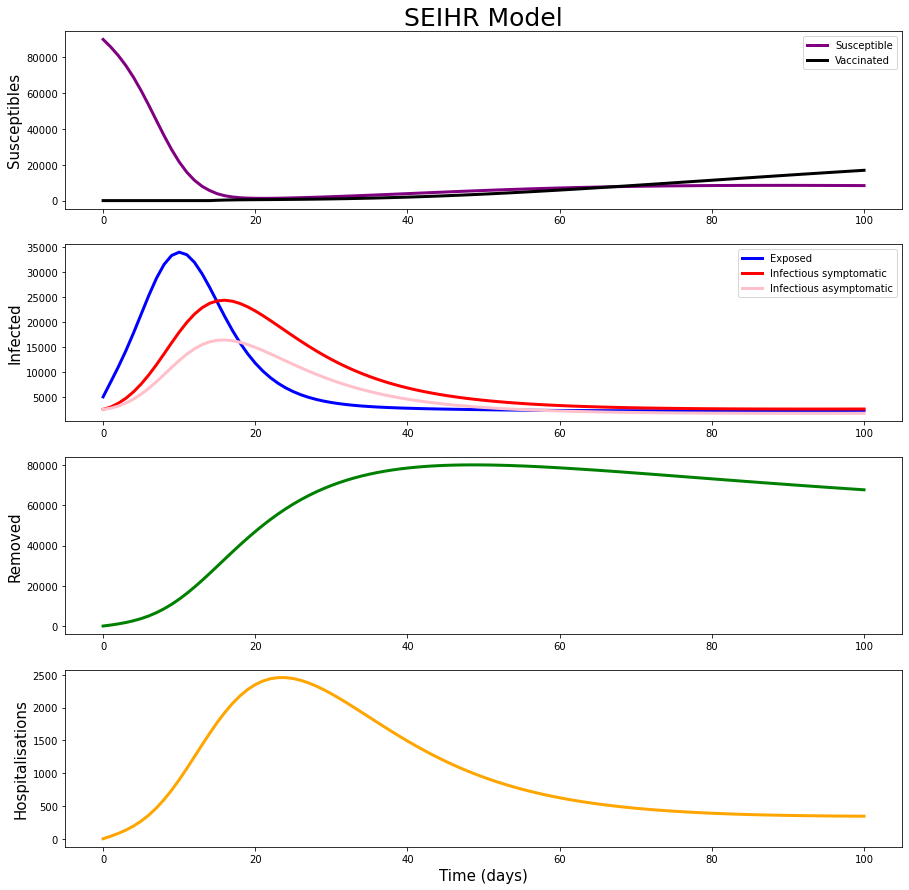

In [5]:
# Rates
beta = 1.4247 
epsilon = 1/5.28
gamma = 1/10 
delta = 1/8.78 
tau = 0.25 
rho = 0.1
omega = 1/100
d = 0.6
h = 0.15 

# Population sizes
N = 100000   #total
S0 = 90000
E0 = 5000
I_S0 = 2500
I_A0 = 2500
H0 = 0
R0 = 0
V0 = 0

# Time values
t_start = 0
days = 100
t_step=1.0

# Vaccination parameters
sigma = 0.04  
eta = 0.9
vaccinetime = 15 #day vaccination is rolled out


InitialVals = [S0, E0, I_S0, I_A0, H0, R0, V0]




# SEIHR model with vaccination set to 0
def SEIHRmodel(IVS,time):  
    
    FOI = beta*(tau*IVS[3] + IVS[2] + rho*IVS[4]) 
    
    S = - FOI * IVS[0]/N + omega*IVS[5]
    E = FOI *IVS[0]/N - epsilon*IVS[1]
    I_S = epsilon*d*IVS[1] - gamma*IVS[2]
    I_A = epsilon*(1 - d)*IVS[1] - gamma*IVS[3]
    H = gamma*h*IVS[2] - delta*IVS[4]
    R = delta*IVS[4] + gamma*(1 - h)*IVS[2] + gamma*IVS[3] - omega*IVS[5]
    V = 0
    
    Y = [S, E, I_S, I_A, H, R, V]
    return(Y) 

# SEIHRV model, adding vaccine
def SEIHRVmodel(IVS,time):  
    
    FOI = beta*(tau*IVS[3] + IVS[2] + rho*IVS[4]) 
    
    S = - FOI * IVS[0]/N + omega*IVS[5] - sigma*IVS[0]
    E = FOI * IVS[0]/N - epsilon*IVS[1] + (1 - eta)*FOI*IVS[6]/N
    I_S = epsilon*d*IVS[1] - gamma*IVS[2]
    I_A = epsilon*(1 - d)*IVS[1] - gamma*IVS[3]
    H = gamma*h*IVS[2] - delta*IVS[4]
    R = delta*IVS[4] + gamma*(1 - h)*IVS[2] + gamma*IVS[3] - omega*IVS[5]
    V = sigma*IVS[0] - (1 - eta)*FOI*IVS[6]/N
    
    Y = [S, E, I_S, I_A, H, R, V]
    return(Y)


t1 = np.arange(t_start, vaccinetime, t_step) # time up until vaccine implemented
t2 = np.arange(vaccinetime - t_step, days + t_step, t_step) # time after vaccine implemented

values1 = spi.odeint(SEIHRmodel, InitialVals, t1) # pre-vaccine 
values2 = spi.odeint(SEIHRVmodel, values1[-1], t2) # post-vaccine


total_values = np.concatenate((values1, values2[1:]), axis = 0) # Combining pre- and post- vaccine info


# PLOTTING:
plt.figure(figsize=(15, 15))

plt.subplot(411)
plt.plot(total_values[:,0], 'purple', linewidth = 3, label = 'Susceptible')
plt.plot(total_values[:,6], 'black', linewidth = 3, label = 'Vaccinated')
plt.legend(loc=0)
plt.title('SEIHR Model', fontsize=25)
plt.ylabel('Susceptibles', fontsize=15)

plt.subplot(412)
plt.plot(total_values[:,1], 'blue', linewidth = 3, label = 'Exposed')
plt.plot(total_values[:,2], 'red', linewidth = 3, label = 'Infectious symptomatic')
plt.plot(total_values[:,3], 'pink', linewidth = 3, label = 'Infectious asymptomatic')
plt.legend(loc=0)
plt.ylabel('Infected', fontsize=15)

plt.subplot(413)
plt.plot(total_values[:,5], 'green', linewidth = 3, label='Removed')
plt.ylabel('Removed', fontsize=15)

plt.subplot(414)
plt.plot(total_values[:,4], 'orange', linewidth = 3, label = 'Hospitalised')
plt.xlabel('Time (days)', fontsize=15)
plt.ylabel('Hospitalisations', fontsize=15)

plt.show()

## Vaccination arrival time - V not in ODEs <a id="SEIHRVVaxfunc"></a>

It's annoying to have to define different functions for different cases and concatenate them - especially if I was then stopping vaccinations at some point, and then adding lockdown would have the same issue. Instead, can we have a function for number of vaccinated people that is time-dependent and increases from the vaccine arrival time, and its maximum is $\eta * N$ (which is the total number of people who can be 'successfully' vaccinated - ie vaccinated and will not be re-infected).

I use the following equation for Vaccination:

$$ V(t) = \eta N( 1 - e^{-\kappa(t - T))}$$

where $N$ total population, $\kappa$ the speed of vaccine rollout, and $T$ the deployment day. For $\kappa \approx 0.01$ this gives around 8,000 people vaccinated a day per million (lines up with COVID-19 data).

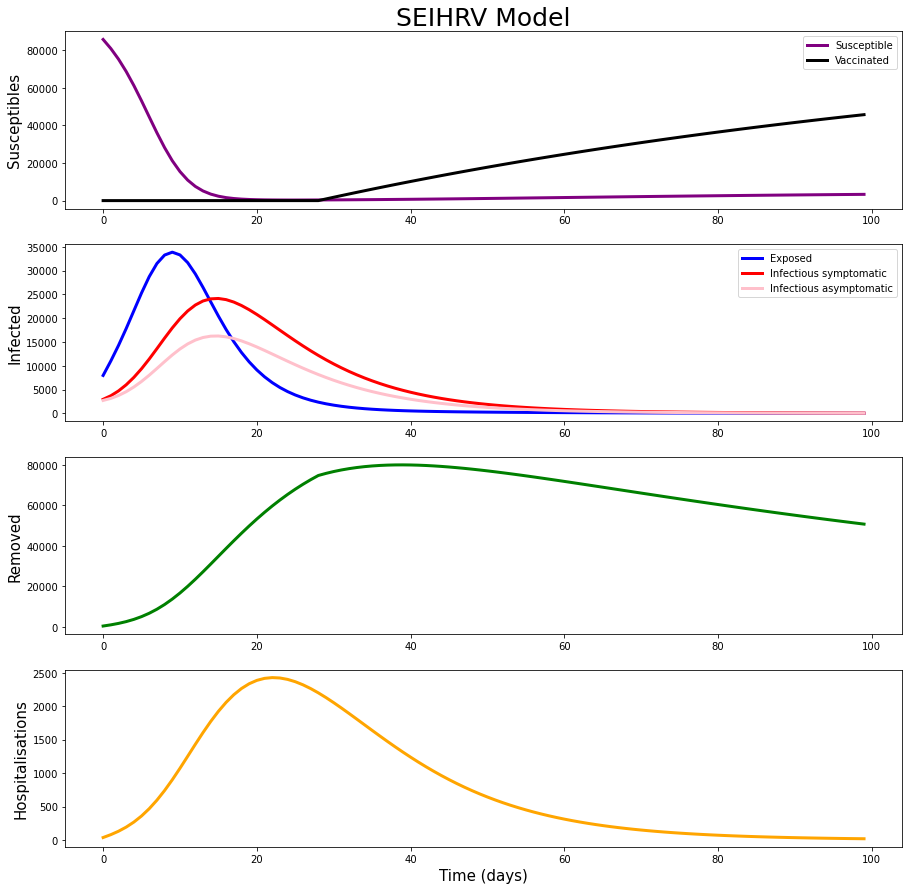

In [7]:
# Rates
beta = 1.4247 
epsilon = 1/5.28
gamma = 1/10
delta = 1/8.78 
tau = 0.25 
rho = 0.2
omega = 1/800
d = 0.6 
h = 0.15

N = 100000 
S0 = 90000
E0 = 5000
I_S0 = 2500
I_A0 = 2500
H0 = 0
R0 = 0
V0 = 0

t_start = 0
days = 100
t_step=1.0

eta = 0.9
kappa = 0.01 #determines speed of rollout
vaccinetime = 30

InitialVals = [S0, E0, I_S0, I_A0, H0, R0, V0]


def vacc_rate(time):
    if time >= vaccinetime:
        vaccinated = eta*N*( 1 - np.exp(-kappa*(time - vaccinetime)))
    else:
        vaccinated = 0
    
    return vaccinated

def SEIHRVmodel(IVS,time):  
    
    FOI = beta*(tau*IVS[3] + IVS[2] + rho*IVS[4]) 
    
    S = - FOI * IVS[0]/N + omega*IVS[5]
    E = FOI *IVS[0]/N - epsilon*IVS[1]
    I_S = epsilon*d*IVS[1] - gamma*IVS[2]
    I_A = epsilon*(1 - d)*IVS[1] - gamma*IVS[3]
    H = gamma*h*IVS[2] - delta*IVS[4]
    R = delta*IVS[4] + gamma*(1 - h)*IVS[2] + gamma*IVS[3] - omega*IVS[5]
    V = 0
    
    Y = [S, E, I_S, I_A, H, R, V]
    return(Y)



values = np.empty((0, 7))
for day in range(1, days+1):
    if day < vaccinetime:
        values = np.concatenate([values, spi.odeint(SEIHRVmodel, InitialVals, [day, day+1])[[1],:]])
        InitialVals = spi.odeint(SEIHRVmodel, InitialVals, [day, day+1])[1,:]
        
    else: 
        values = np.concatenate([values, spi.odeint(SEIHRVmodel, InitialVals, [day, day+1])[[1],:]])
        
        dV = vacc_rate(day+1) - vacc_rate(day) #number of new vaccinations for day 'day'
        
        values[day-1,0] = values[day-1,0] - dV*(values[day-1,0]/(values[day-1,0]+values[day-1,5])) #remove some people from S (move into V)
        values[day-1,5] = values[day-1,5] - dV*(values[day-1,5]/(values[day-1,0]+values[day-1,5])) #remove some people from R (move into V)
        
        values[day-1,6] = values[day-1,6] + dV #everyone vaccinated moves into V)
        
        #edit initial conditions based on these additions
        InitialVals = [values[day-1,0], values[day-1,1], values[day-1,2], values[day-1,3], values[day-1,4], values[day-1,5], values[day-1,6]]

        
# PLOTTING:
plt.figure(figsize=(15, 15))

plt.subplot(411)
plt.plot(values[:,0], 'purple', linewidth = 3, label='Susceptible')
plt.plot(values[:,6], 'black', linewidth = 3, label = 'Vaccinated')
plt.legend(loc=0)
plt.title('SEIHRV Model', fontsize=25)
plt.ylabel('Susceptibles', fontsize=15)

plt.subplot(412)
plt.plot(values[:,1], 'blue', linewidth = 3, label='Exposed')
plt.plot(values[:,2], 'red', linewidth = 3, label = 'Infectious symptomatic')
plt.plot(values[:,3], 'pink', linewidth = 3, label = 'Infectious asymptomatic')
plt.legend(loc=0)
plt.ylabel('Infected', fontsize=15)

plt.subplot(413)
plt.plot(values[:,5], 'green', linewidth = 3, label='Removed')
plt.ylabel('Removed', fontsize=15)

plt.subplot(414)
plt.plot(values[:,4], 'orange', linewidth = 3, label = 'Hospitalised')
plt.xlabel('Time (days)', fontsize=15)
plt.ylabel('Hospitalisations', fontsize=15)

plt.show()

## Adding a 'susceptible vaccinated' compartment <a id="SEIHRVVaxsusc"></a>

After speaking with Nathan he mentioned how if there was no outbreak ($E(0)=I^S(0)=I^A(0)=0$), with what I've done above after enough time, every single person will be in 'vaccinated'. He suggested adding another compartment for those who get the vaccine but are still susceptible (as it's not 100% effective), as before I was directly putting them into exposed - but obviously just because it's not effective that doesn't guarantee they will get infected. From this, I now have it so that for no outbreak after a long amount of time, the amount of vaccinated immune people ($V^I$) goes to $\eta N$ and the susceptibles ($S+V^S$) goes to $(1-\eta)N$. This leads to the following system of equations:

$$\dfrac{dS}{dt} = - \lambda \frac{S}{N} + \omega R - \sigma S$$ 

$$\dfrac{dE}{dt} =  \lambda \left( \frac{S+V^S}{N} \right) - \epsilon E$$ 

$$\dfrac{dI^S}{dt} = \epsilon d E - \gamma I^S$$

$$\dfrac{dI^A}{dt} = \epsilon (1-d) E - \gamma I^A$$

$$\dfrac{dH}{dt} = \gamma h I^S - \delta H$$

$$\dfrac{dR}{dt} = \delta H + \gamma (1 - h)I^S + \gamma I^A - \omega R$$

$$\dfrac{dV^I}{dt} = \sigma \eta S $$

$$\dfrac{dV^S}{dt} = \sigma (1 - \eta) S - \lambda \frac{V^S}{N}$$

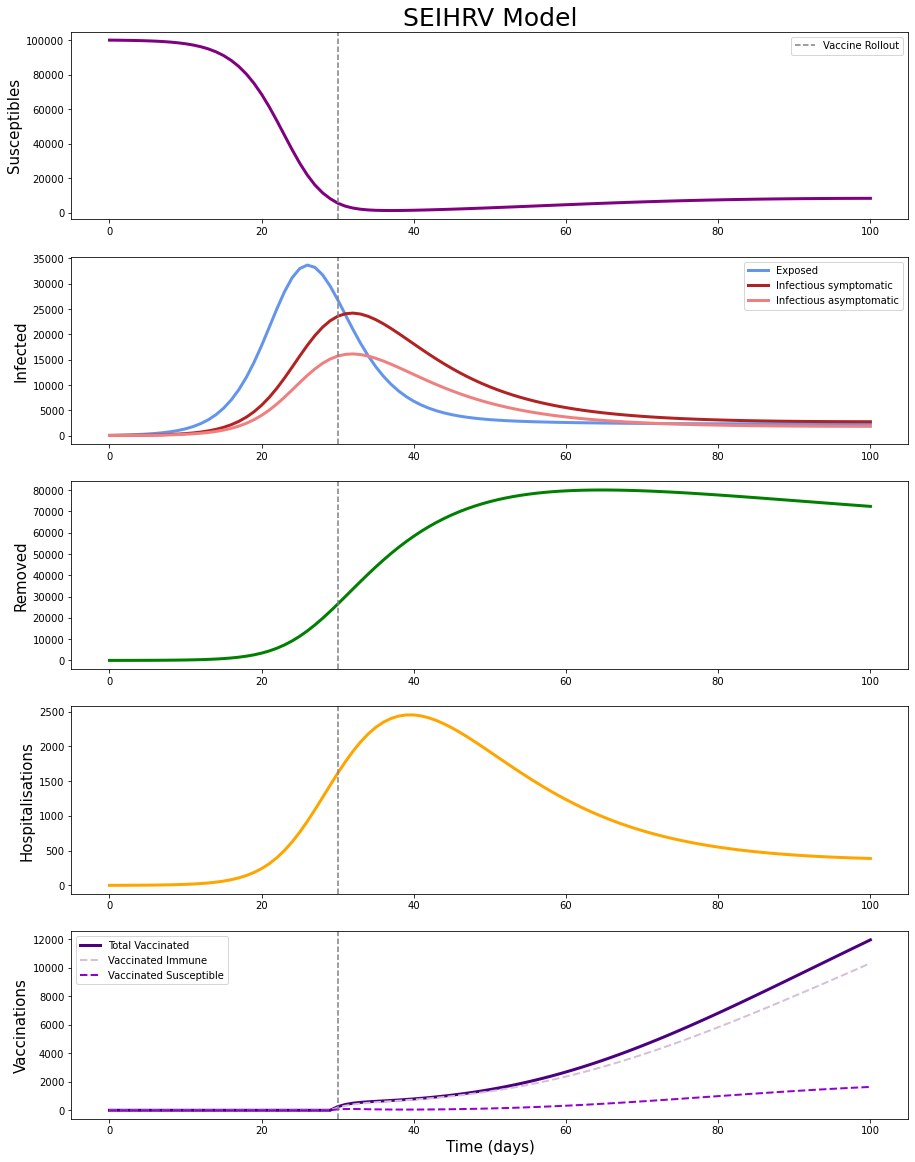

In [16]:
# Rates
beta = 1.4247 
epsilon = 1/5.28
gamma = 1/10 
delta = 1/8.78 
tau = 0.25 
rho = 0.1
omega = 1/100
d = 0.6
h = 0.15 

# Population sizes
N = 100000   #total
S0 = 99900
E0 = 50
I_S0 = 25
I_A0 = 25
H0 = 0
R0 = 0
V_I0 = 0
V_S0 = 0

# Time values
t_start = 0
days = 100
t_step=1.0

# Vaccination parameters
sigma = 0.04
eta = 0.7
vaccinetime = 30 #day vaccination is rolled out


InitialVals = [S0, E0, I_S0, I_A0, H0, R0, V_I0, V_S0]

# SEIHR model with vaccination set to 0
def SEIHRmodel(IVS,time):  
    
    FOI = beta*(tau*IVS[3] + IVS[2] + rho*IVS[4])
    
    S = - FOI * IVS[0]/N + omega*IVS[5]
    E = FOI * IVS[0]/N - epsilon*IVS[1]
    I_S = epsilon*d*IVS[1] - gamma*IVS[2]
    I_A = epsilon*(1 - d)*IVS[1] - gamma*IVS[3]
    H = gamma*h*IVS[2] - delta*IVS[4]
    R = delta*IVS[4] + gamma*(1 - h)*IVS[2] + gamma*IVS[3] - omega*IVS[5]
    V_I = 0
    V_S = 0
    
    Y = [S, E, I_S, I_A, H, R, V_I, V_S]
    return(Y) 

# SEIHRV model, adding vaccine
def SEIHRVmodel(IVS,time):  
    
    FOI = beta*(tau*IVS[3] + IVS[2] + rho*IVS[4])
    
    S = - FOI * IVS[0]/N + omega*IVS[5] - sigma*IVS[0]
    E = FOI * (IVS[0]+IVS[7])/N - epsilon*IVS[1]
    I_S = epsilon*d*IVS[1] - gamma*IVS[2]
    I_A = epsilon*(1 - d)*IVS[1] - gamma*IVS[3]
    H = gamma*h*IVS[2] - delta*IVS[4]
    R = delta*IVS[4] + gamma*(1 - h)*IVS[2] + gamma*IVS[3] - omega*IVS[5]
    V_I = sigma*eta*IVS[0]
    V_S = sigma*(1-eta)*IVS[0] - FOI*IVS[7]/N
    
    Y = [S, E, I_S, I_A, H, R, V_I, V_S]
    return(Y) 


t1 = np.arange(t_start, vaccinetime, t_step) # time up until vaccine implemented
t2 = np.arange(vaccinetime - t_step, days + t_step, t_step) # time after vaccine implemented

values1 = spi.odeint(SEIHRmodel, InitialVals, t1) # pre-vaccine 
values2 = spi.odeint(SEIHRVmodel, values1[-1], t2) # post-vaccine

total_values = np.concatenate((values1, values2[1:]), axis = 0) # Combining pre- and post- vaccine info

total_vaccinated = total_values[:,6] + total_values[:,7]

# Plotting:
plt.figure(figsize=(15, 20))


plt.subplot(511)
plt.plot(total_values[:,0], 'purple', linewidth = 3)
plt.axvline(vaccinetime, color = 'grey', linestyle='dashed', label = 'Vaccine Rollout')
plt.title('SEIHRV Model', fontsize=25)
plt.legend(loc=0)
plt.ylabel('Susceptibles', fontsize=15)

plt.subplot(512)
plt.plot(total_values[:,1], 'cornflowerblue', linewidth = 3, label='Exposed')
plt.plot(total_values[:,2], 'firebrick', linewidth = 3, label = 'Infectious symptomatic')
plt.plot(total_values[:,3], 'lightcoral', linewidth = 3, label = 'Infectious asymptomatic')
plt.axvline(vaccinetime, color = 'grey', linestyle='dashed')
plt.legend(loc=0)
plt.ylabel('Infected', fontsize=15)

plt.subplot(513)
plt.plot(total_values[:,5], 'green', linewidth = 3, label='Removed')
plt.axvline(vaccinetime, color = 'grey', linestyle='dashed')
plt.ylabel('Removed', fontsize=15)

plt.subplot(514)
plt.plot(total_values[:,4], 'orange', linewidth = 3, label = 'Hospitalised')
plt.axvline(vaccinetime, color = 'grey', linestyle='dashed')
plt.ylabel('Hospitalisations', fontsize=15)

plt.subplot(515)
plt.plot(total_vaccinated, 'indigo', linewidth = 3, label='Total Vaccinated')
plt.plot(total_values[:,6], 'thistle', linewidth = 2, linestyle = "--", label='Vaccinated Immune')
plt.plot(total_values[:,7], 'darkviolet', linewidth = 2, linestyle = "--", label='Vaccinated Susceptible')
plt.axvline(vaccinetime, color = 'grey', linestyle='dashed')
plt.legend(loc=0)
plt.xlabel('Time (days)', fontsize=15)
plt.ylabel('Vaccinations', fontsize = 15)

plt.show()

# Splitting S/E/I/H/R into vaccinated and unvaccinated, adding death, NGM

The full set of equations is written elsewhere, but it is essentially what we had previously but separated into unvaccinated (U) and vaccinated (V) compartments. So there is a susceptible/exposed/infected/hospitalised/recovered/dead unvaccinated and vaccinated (that's 14 compartments), as well as a vaccinated immune compartment (where $\eta \times 100$% of the vaccinated go - efficacy dependent). The rates for vaccinated and unvaccinated are all the same at the moment, except for probability of hospitalisation where I have a $h_1$ (U) and $h_2$ (V) - but for now I have set them equal.

With the addition of 'Dead' (D), the probability of death (given hospitalisation) is $k$ - so the rate at which people move from H to D is $\delta k$ and H to R is $\delta (1-k)$.

This also means the new force of infection is:
$$
\lambda = \beta(\tau (I^{AU} + I^{AV}) + (I^{SU} + I^{SV}) + \rho (H^U + H^V))
$$

Finally, I used a Next Generation Matrix (NGM) method to adjust my rates, such that $R_0 = 3$. I increased $\gamma$ and $\delta$ slightly and reduced $d$ to be more in line with other work down to $0.1$. I did it by hand but I will also write code further down to do it.

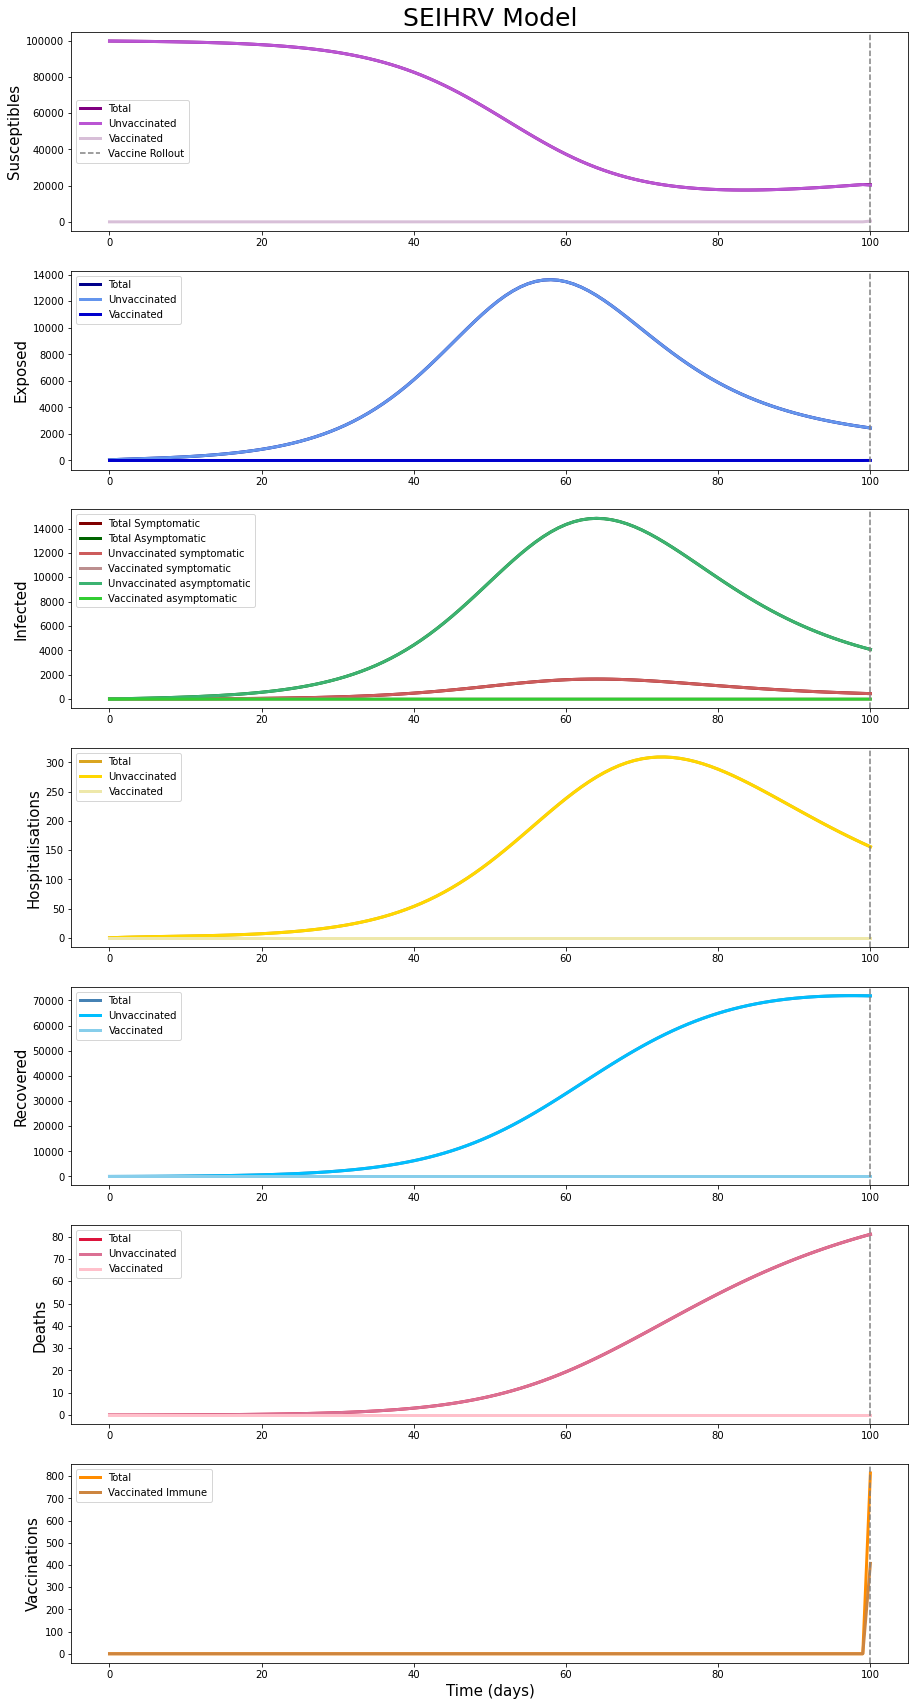

In [41]:
# Rates
beta = 1.24 
epsilon = 1/5.28
gamma = 1/7
delta = 1/10 
tau = 0.25 
rho = 0.1
omega = 1/100
k =  0.06  # probability of death (given hospitalisation)
d = 0.1
h1 = 0.15  # probability of hospitalisation given not vaccinated
h2 = 0.15  # probability of hospitalisation given vaccinated

# Population sizes
N = 100000 
# Unvaccinated populations:
S_U0 = 99900
E_U0 = 50
I_SU0 = 25
I_AU0 = 25
H_U0 = 0
R_U0 = 0
D_U0 = 0
# Vaccinated populations:
S_V0 = 0
S_VI0 = 0
E_V0 = 0
I_SV0 = 0
I_AV0 = 0
H_V0 = 0
R_V0 = 0
D_V0 = 0

# Time values
t_start = 0
days = 100
t_step=1.0

# Vaccination parameters
sigma = 0.04
eta = 0.5
vaccinetime = 100

InitialVals = [S_U0, E_U0, I_SU0, I_AU0, H_U0, R_U0, D_U0, S_V0, S_VI0, E_V0, I_SV0, I_AV0, H_V0, R_V0, D_V0]

# SEIHR model with vaccination set to 0
def SEIHRmodel(IVS,time):  
    
    FOI = beta*(tau*IVS[3] + IVS[2] + rho*IVS[4])
    
    S_U  = omega*IVS[5] - FOI*IVS[0]/N
    E_U  = FOI*IVS[0]/N - epsilon*IVS[1]
    I_SU = epsilon*d*IVS[1] - gamma*IVS[2]
    I_AU = epsilon*(1-d)*IVS[1] - gamma*IVS[3]
    H_U  = gamma*h1*IVS[2] - delta*IVS[4]
    R_U  = delta*(1-k)*IVS[4] + gamma*(1-h1)*IVS[2] + gamma*IVS[3] - omega*IVS[5]
    D_U  = delta*k*IVS[4]
    
    S_V  = 0
    S_VI = 0
    E_V  = 0
    I_SV = 0
    I_AV = 0
    H_V  = 0
    R_V  = 0
    D_V  = 0
    
    Y = [S_U, E_U, I_SU, I_AU, H_U, R_U, D_U, S_V, S_VI, E_V, I_SV, I_AV, H_V, R_V, D_V]
    return(Y) 

# SEIHRV model, adding vaccine
def SEIHRVmodel(IVS,time): 
    
    FOI = beta*(tau*(IVS[3] + IVS[11]) + IVS[2] + IVS[10] + rho*(IVS[4] + IVS[12]))
    
    S_U  = omega*IVS[5] - FOI*IVS[0]/N - sigma*IVS[0]
    E_U  = FOI*IVS[0]/N - epsilon*IVS[1]
    I_SU = epsilon*d*IVS[1] - gamma*IVS[2]
    I_AU = epsilon*(1-d)*IVS[1] - gamma*IVS[3]
    H_U  = gamma*h1*IVS[2] - delta*IVS[4]
    R_U  = delta*(1-k)*IVS[4] + gamma*(1-h1)*IVS[2] + gamma*IVS[3] - omega*IVS[5]
    D_U  = delta*k*IVS[4]
    
    S_V  = omega*IVS[13] - FOI*IVS[7]/N + sigma*(1-eta)*IVS[0]
    S_VI = sigma*eta*IVS[0]
    E_V  = FOI*IVS[7]/N - epsilon*IVS[9]
    I_SV = epsilon*d*IVS[9] - gamma*IVS[10]
    I_AV = epsilon*(1-d)*IVS[9] - gamma*IVS[11]
    H_V  = gamma*h2*IVS[10] - delta*IVS[12]
    R_V  = delta*(1-k)*IVS[12] + gamma*(1-h2)*IVS[10] + gamma*IVS[11] - omega*IVS[13]
    D_V  = delta*k*IVS[12]
    
    Y = [S_U, E_U, I_SU, I_AU, H_U, R_U, D_U, S_V, S_VI, E_V, I_SV, I_AV, H_V, R_V, D_V]
    return(Y) 


t1 = np.arange(t_start, vaccinetime, t_step) # time up until vaccine implemented
t2 = np.arange(vaccinetime - t_step, days + t_step, t_step) # time after vaccine implemented

values1 = spi.odeint(SEIHRmodel, InitialVals, t1) # pre-vaccine 
values2 = spi.odeint(SEIHRVmodel, values1[-1], t2) # post-vaccine

total_values = np.concatenate((values1, values2[1:]), axis = 0) # Combining pre- and post- vaccine info

# Getting the totals
total_susceptible = total_values[:,0] + total_values[:,7]
total_exposed = total_values[:,1] + total_values[:,9]
total_infectedS = total_values[:,2] + total_values[:,10]
total_infectedA = total_values[:,3] + total_values[:,11]
total_hospitalised = total_values[:,4] + total_values[:,12]
total_recovered = total_values[:,5] + total_values[:,13]
total_dead = total_values[:,6] + total_values[:, 14]
total_vaccinated = total_values[:,7]+ total_values[:,8] + total_values[:,9]+ total_values[:,10] + total_values[:,11]+ total_values[:,12] + total_values[:,11]+ total_values[:,12]

# Plotting:
plt.figure(figsize=(15, 30))

plt.subplot(711) # SUSCEPTIBLES
plt.plot(total_susceptible, 'purple', linewidth = 3, label = 'Total')
plt.plot(total_values[:,0], 'mediumorchid', linewidth = 3, label = 'Unvaccinated')
plt.plot(total_values[:,7], 'thistle', linewidth = 3, label = 'Vaccinated')
plt.axvline(vaccinetime, color = 'grey', linestyle='dashed', label = 'Vaccine Rollout')
plt.title('SEIHRV Model', fontsize=25)
plt.legend(loc=0)
plt.ylabel('Susceptibles', fontsize=15)

plt.subplot(712) # EXPOSED
plt.plot(total_exposed, 'darkblue', linewidth=3, label = 'Total')
plt.plot(total_values[:,1], 'cornflowerblue', linewidth = 3, label='Unvaccinated')
plt.plot(total_values[:,9], 'mediumblue', linewidth = 3, label='Vaccinated')
plt.axvline(vaccinetime, color = 'grey', linestyle='dashed')
plt.legend(loc=0)
plt.ylabel('Exposed', fontsize=15)

plt.subplot(713) # INFECTIOUS
plt.plot(total_infectedS, 'maroon', linewidth=3, label = 'Total Symptomatic')
plt.plot(total_infectedA, 'darkgreen', linewidth=3, label = 'Total Asymptomatic')
plt.plot(total_values[:,2], 'indianred', linewidth = 3, label = 'Unvaccinated symptomatic')
plt.plot(total_values[:,10], 'rosybrown', linewidth = 3, label = 'Vaccinated symptomatic')
plt.plot(total_values[:,3], 'mediumseagreen', linewidth = 3, label = 'Unvaccinated asymptomatic')
plt.plot(total_values[:,11], 'limegreen', linewidth = 3, label = 'Vaccinated asymptomatic')
plt.axvline(vaccinetime, color = 'grey', linestyle='dashed')
plt.legend(loc=0)
plt.ylabel('Infected', fontsize=15)

plt.subplot(714) #HOSPITALISED
plt.plot(total_hospitalised, 'goldenrod', linewidth=3, label = 'Total')
plt.plot(total_values[:,4], 'gold', linewidth = 3, label = 'Unvaccinated')
plt.plot(total_values[:,12], 'palegoldenrod', linewidth = 3, label = 'Vaccinated')
plt.axvline(vaccinetime, color = 'grey', linestyle='dashed')
plt.legend(loc=0)
plt.ylabel('Hospitalisations', fontsize=15)

plt.subplot(715) # RECOVERED
plt.plot(total_recovered, 'steelblue', linewidth=3, label = 'Total')
plt.plot(total_values[:,5], 'deepskyblue', linewidth = 3, label='Unvaccinated')
plt.plot(total_values[:,13], 'skyblue', linewidth = 3, label='Vaccinated')
plt.axvline(vaccinetime, color = 'grey', linestyle='dashed')
plt.legend(loc=0)
plt.ylabel('Recovered', fontsize=15)

plt.subplot(716) # DEAD
plt.plot(total_dead, 'crimson', linewidth=3, label = 'Total')
plt.plot(total_values[:,6], 'palevioletred', linewidth = 3, label='Unvaccinated')
plt.plot(total_values[:,14], 'pink', linewidth = 3, label='Vaccinated')
plt.axvline(vaccinetime, color = 'grey', linestyle='dashed')
plt.legend(loc=0)
plt.ylabel('Deaths', fontsize=15)

plt.subplot(717) # VACCINATED
plt.plot(total_vaccinated, 'darkorange', linewidth = 3, label='Total')
plt.plot(total_values[:,8], 'peru', linewidth = 3, label='Vaccinated Immune')
plt.axvline(vaccinetime, color = 'grey', linestyle='dashed')
plt.legend(loc=0)
plt.xlabel('Time (days)', fontsize=15)
plt.ylabel('Vaccinations', fontsize = 15)

plt.show()